<p style = "font-size : 50px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px;"><strong>Chronic Kidney Disease Prediction — Explicabilité des Modèles d'Ensemble</strong></p>

<a id='0'></a>
<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px;"><strong>Table des matières</strong></p>

* [Données et préparation](#prep)
* [Data Pre Processing](#3.0)
* [Feature Encoding](#4.0)
* [Model Building (Random Forest et XGBoost)](#5.0)
* [Section 6 : Explicabilité des Modèles de Combinaison](#6.0)
    * [6.1 TreeSHAP — Forêt Aléatoire](#6.1)
    * [6.2 Distillation de connaissances](#6.2)
    * [6.3 Interactions SHAP — XGBoost](#6.3)

<a id='prep'></a>
<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>Données et préparation</strong></p>

Dataset UCI : 400 patients, 24 variables cliniques. Objectif : prédire la présence de maladie rénale chronique (CKD).

In [25]:
# Imports et chargement des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
%matplotlib inline
pd.set_option('display.max_columns', 26)

# Chargement du dataset (adapter le chemin si nécessaire)
df = pd.read_csv('/kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [26]:
# Suppression de la colonne id
df.drop('id', axis=1, inplace=True)

# Renommage des colonnes (noms longs pour lisibilité clinique et Section 6)
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


<a id='3.0'></a>
<p style = "font-size : 40px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px;"><strong>Data Pre Processing</strong></p>

In [27]:
# Définition des colonnes numériques et catégorielles
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [28]:
for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

packed_cell_volume has ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '\t?' '52' '14' '22' '18' '42' '17' '46' '23'
 '19' '25' '41' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54'] values

white_blood_cell_count has ['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '\t6200' '7100' '11800' '9400' '5500' '5800'
 '13200' '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800'
 '6500' '13600' '10200' '9000' '14900' '8200' '15200' '5000' '16300'
 '12400' '\t8400' '10500' '4200' '4700' '10900' '8100' '9500' '2200'
 '

In [29]:
# Nettoyage des valeurs incohérentes dans les colonnes catégorielles
df['diabetes_mellitus'].replace(to_replace = {'\tno':'no','\tyes':'yes',' yes':'yes'},inplace=True)
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value='no')
df['class'] = df['class'].replace(to_replace = {'ckd\t': 'ckd', 'notckd': 'not ckd'})

# Encodage de la cible : 0 = CKD (malade), 1 = not CKD (sain)
df['class'] = df['class'].map({'ckd': 0, 'not ckd': 1})
df['class'] = pd.to_numeric(df['class'], errors='coerce')
df.dropna(subset=['class'], inplace=True)



In [30]:
import numpy as np
cols_tab_clean = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']
for col in cols_tab_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lstrip('\t')
        df[col] = df[col].replace({'\t?': np.nan, '?': np.nan})
        df[col] = pd.to_numeric(df[col], errors='coerce')
# Redéfinir num_cols et cat_cols après conversion (ces colonnes deviennent numériques)
num_cols = [col for col in df.columns if df[col].dtype != 'object']
cat_cols = [col for col in df.columns if df[col].dtype == 'object']

In [31]:
cols = ['diabetes_mellitus', 'coronary_artery_disease', 'class', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']

for col in cols:
    print(f"{col} has {df[col].unique()} values\n")

diabetes_mellitus has ['yes' 'no' nan] values

coronary_artery_disease has ['no' 'yes' nan] values

class has [0 1] values

packed_cell_volume has [44. 38. 31. 32. 35. 39. 36. 33. 29. 28. nan 16. 24. 37. 30. 34. 40. 45.
 27. 48. 52. 14. 22. 18. 42. 17. 46. 23. 19. 25. 41. 26. 15. 21. 43. 20.
 47.  9. 49. 50. 53. 51. 54.] values

white_blood_cell_count has [ 7800.  6000.  7500.  6700.  7300.    nan  6900.  9600. 12100.  4500.
 12200. 11000.  3800. 11400.  5300.  9200.  6200.  8300.  8400. 10300.
  9800.  9100.  7900.  6400.  8600. 18900. 21600.  4300.  8500. 11300.
  7200.  7700. 14600.  6300.  7100. 11800.  9400.  5500.  5800. 13200.
 12500.  5600.  7000. 11900. 10400. 10700. 12700.  6800.  6500. 13600.
 10200.  9000. 14900.  8200. 15200.  5000. 16300. 12400. 10500.  4200.
  4700. 10900.  8100.  9500.  2200. 12800. 11200. 19100. 12300. 16700.
  2600. 26400.  8800.  7400.  4900.  8000. 12000. 15700.  4100.  5700.
 11500.  5400. 10800.  9900.  5200.  5900.  9300.  9700.  5100.  6600.] va

In [32]:
# Imputation des valeurs manquantes : fonctions utilisées
def random_value_imputation(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(), feature] = random_sample

def impute_mode(feature):
    mode = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode)

In [33]:
# Imputation des colonnes numériques (KNN Imputer — similarité euclidienne, conforme tp_read.md)
from sklearn.impute import KNNImputer

n_samples = len(df)
k_neighbors = min(5, n_samples) if n_samples >= 1 else 1
if n_samples >= k_neighbors and n_samples > 0:
    knn_imputer = KNNImputer(n_neighbors=k_neighbors)
    df[num_cols] = knn_imputer.fit_transform(df[num_cols])
else:
    # Fallback si trop peu de lignes (ex. après dropna sur class)
    for col in num_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

In [34]:
# Imputation des colonnes catégorielles (red_blood_cells, pus_cell : aléatoire ; reste : mode)
if 'red_blood_cells' in df.columns and df['red_blood_cells'].isna().sum() > 0:
    random_value_imputation('red_blood_cells')
if 'pus_cell' in df.columns and df['pus_cell'].isna().sum() > 0:
    random_value_imputation('pus_cell')
for col in cat_cols:
    if df[col].isna().sum() > 0:
        impute_mode(col)

<a id='4.0'></a>
<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px;"><strong>Feature Encoding</strong></p>

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,36.0,1.2,137.6,4.20,15.4,44.0,7800.0,5.20,1,1,0,0,0,0,0.0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,113.0,18.0,0.8,137.4,4.00,11.3,38.0,6000.0,4.96,0,0,0,0,0,0,0.0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,53.0,1.8,133.8,4.20,9.6,31.0,7500.0,3.80,0,1,0,1,0,1,0.0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,56.0,3.8,111.0,2.50,11.2,32.0,6700.0,3.90,1,0,0,1,1,1,0.0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,26.0,1.4,138.4,3.98,11.6,35.0,7300.0,4.60,0,0,0,0,0,0,0.0


<a id='5.0'></a>
<p style = "font-size : 45px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px;"><strong>Model Building</strong></p>

In [36]:
ind_col = [col for col in df.columns if col != 'class']
dep_col = 'class'
X = df[ind_col]
y = df[dep_col]

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

<a id='5.3'></a>
<p style = "font-size : 25px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>Random Forest Classifier (Bagging)</strong></p>

In [37]:
from sklearn.ensemble import RandomForestClassifier

rd_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 11, max_features = 'sqrt', min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
rd_clf.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of random forest

rd_clf_acc = accuracy_score(y_test, rd_clf.predict(X_test))

print(f"Training Accuracy of Random Forest Classifier is {accuracy_score(y_train, rd_clf.predict(X_train))}")
print(f"Test Accuracy of Random Forest Classifier is {rd_clf_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, rd_clf.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, rd_clf.predict(X_test))}")

Training Accuracy of Random Forest Classifier is 1.0
Test Accuracy of Random Forest Classifier is 0.9416666666666667 

Confusion Matrix :- 
[[71  1]
 [ 6 42]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.95        72
         1.0       0.98      0.88      0.92        48

    accuracy                           0.94       120
   macro avg       0.95      0.93      0.94       120
weighted avg       0.94      0.94      0.94       120



<a id='5.7'></a>
<p style = "font-size : 25px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>XGBoost (Boosting)</strong></p>

In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.5, max_depth = 5, n_estimators = 150)
xgb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of xgboost

xgb_acc = accuracy_score(y_test, xgb.predict(X_test))

print(f"Training Accuracy of XgBoost is {accuracy_score(y_train, xgb.predict(X_train))}")
print(f"Test Accuracy of XgBoost is {xgb_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, xgb.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, xgb.predict(X_test))}")

Training Accuracy of XgBoost is 1.0
Test Accuracy of XgBoost is 0.95 

Confusion Matrix :- 
[[71  1]
 [ 5 43]]

Classification Report :- 
               precision    recall  f1-score   support

         0.0       0.93      0.99      0.96        72
         1.0       0.98      0.90      0.93        48

    accuracy                           0.95       120
   macro avg       0.96      0.94      0.95       120
weighted avg       0.95      0.95      0.95       120



<a id='6.0'></a>
<p style = "font-size : 45px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #f9b208; border-radius: 5px 5px;"><strong>Section 6 : Explicabilité des Modèles de Combinaison (TP Cas Pratique 3)</strong></p>

Les modèles d'ensemble (forêt aléatoire, XGBoost) atteignent une excellente précision (proche de 98 %) sur le diagnostic de maladie rénale chronique, mais leur décision reste **opaque** : le clinicien ne peut pas accepter un diagnostic sans justification causale. Le **théorème de Condorcet** explique pourquoi l'agrégation par vote améliore la performance ; en contrepartie, la **dimension de Vapnik-Chervonenkis** explose et la frontière de décision devient humainement ininterprétable. Ce TP introduit une couche d'**ingénierie explicative** pour désopacifier ces modèles. Quatre méthodes seront mises en œuvre : **TreeSHAP** (attributions causales exactes pour la forêt), **distillation de connaissances** (transfert de la forêt vers un arbre unique interprétable), et l'**indice d'interaction SHAP** pour XGBoost (interactions entre biomarqueurs et comorbidités).

<a id='6.1'></a>
<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>6.1 — Explicabilité Globale de la Forêt Aléatoire via TreeSHAP</strong></p>

Les approches locales par perturbation comme **LIME** sont souvent instables sur des espaces non linéaires : l'échantillonnage aléatoire peut franchir des frontières de décision et produire des explications incohérentes. **SHAP** (SHapley Additive exPlanations) s'ancre dans la **théorie des jeux coopératifs** de Shapley : chaque variable est un "joueur" et sa valeur SHAP est sa contribution équitable à la prédiction. **TreeSHAP** exploite la structure interne des arbres pour calculer ces valeurs en temps polynomial **O(T·L·D²)** au lieu de O(2^M), avec un calcul **exact** (non approché). La propriété d'**additivité locale** garantit que la somme des valeurs SHAP pour un patient égale la prédiction du modèle moins la prédiction moyenne. Le **beeswarm plot** synthétise l'importance globale, la direction (positif = pousse vers CKD) et la magnitude des variables en un seul graphique.

In [39]:
# Installation des bibliothèques nécessaires (à exécuter une seule fois)
!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initialisation de l'affichage interactif SHAP dans Jupyter
shap.initjs()

print("✅ Bibliothèques chargées avec succès")
print(f"   - SHAP version : {shap.__version__}")

✅ Bibliothèques chargées avec succès
   - SHAP version : 0.50.0


`shap.TreeExplainer` exploite la structure interne de la forêt (nœuds, feuilles) pour calculer les **attributions causales exactes** de chaque variable pour chaque patient du jeu de test. Le résultat `shap_values_rf` est une **liste de 2 matrices** (une par classe : 0 = CKD, 1 = not CKD), chaque matrice ayant la forme (n_test, n_features).

In [40]:
# --- Calcul des valeurs SHAP pour le modèle Random Forest (rd_clf) ---

# Instanciation de l'explainer arborescent : exploite la structure interne de rd_clf
explainer_rf = shap.TreeExplainer(rd_clf)

print("⏳ Calcul des valeurs SHAP en cours...")
shap_values_rf = explainer_rf.shap_values(X_test)

# Adapter le format selon la version SHAP (liste de 2 matrices vs array de (n_features, 2) par sample)
if hasattr(shap_values_rf, 'shape') and len(shap_values_rf) == X_test.shape[0] and np.array(shap_values_rf[0]).ndim == 2:
    shap_classe0 = np.array([shap_values_rf[i][:, 0] for i in range(len(shap_values_rf))])
else:
    shap_classe0 = shap_values_rf[0] if isinstance(shap_values_rf, list) else shap_values_rf

print(f"✅ Calcul terminé.")
print(f"   Forme du tenseur SHAP (classe CKD) : {shap_classe0.shape}")
print(f"   → {shap_classe0.shape[0]} patients × {shap_classe0.shape[1]} variables cliniques")

⏳ Calcul des valeurs SHAP en cours...
✅ Calcul terminé.
   Forme du tenseur SHAP (classe CKD) : (120, 24)
   → 120 patients × 24 variables cliniques


**Lecture du beeswarm plot** : axe Y = variables classées par importance globale (somme des |SHAP|) ; axe X = valeur SHAP (positive = pousse vers CKD, négative = pousse vers non-CKD) ; **couleur** = valeur réelle de la variable (rouge = valeur haute, bleu = valeur basse) ; un point = un patient du jeu de test.

In [41]:
print(type(shap_values_rf))
print(len(shap_values_rf) if hasattr(shap_values_rf, '__len__') else 'N/A')
print([getattr(x, 'shape', None) for x in (shap_values_rf[:3] if hasattr(shap_values_rf, '__len__') else [])])

<class 'numpy.ndarray'>
120
[(24, 2), (24, 2), (24, 2)]


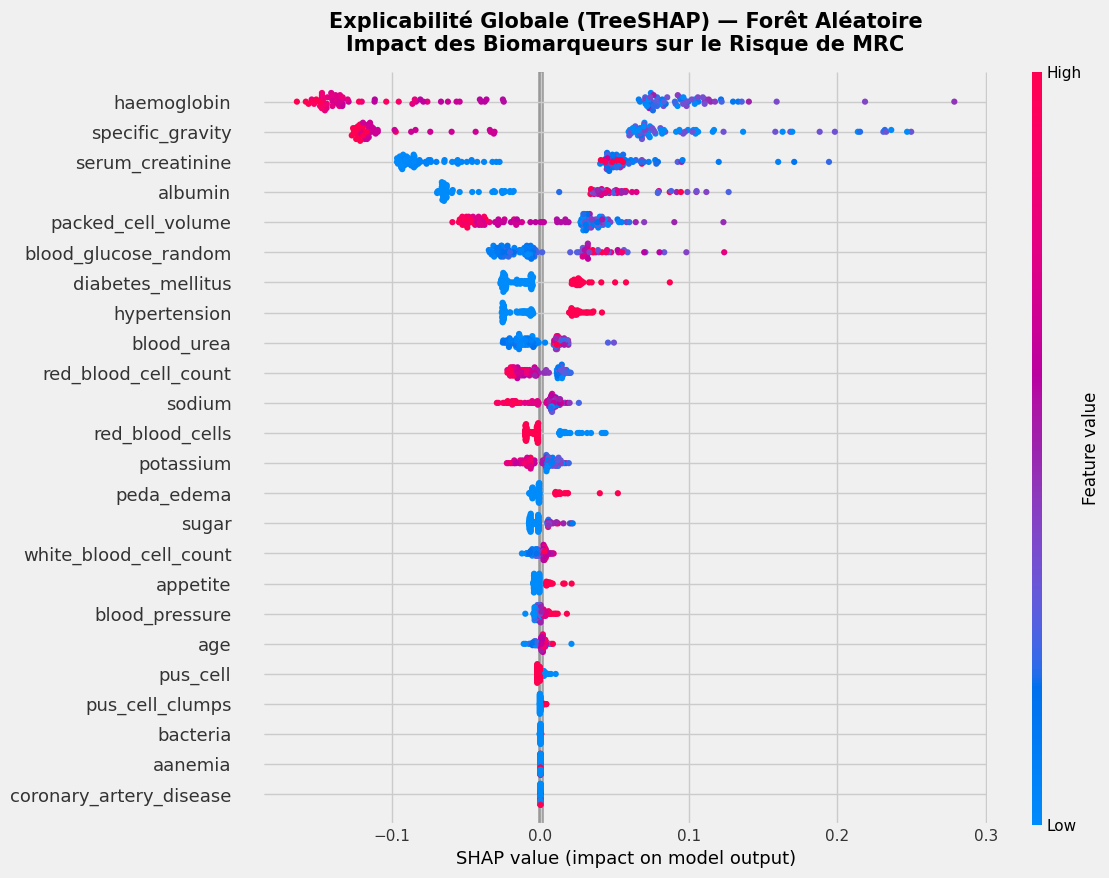

In [42]:
# --- Visualisation : Beeswarm Plot (Graphique en Essaim) ---
# Fixer la graine pour reproductibilité du positionnement des points (jitter)
np.random.seed(42)
# Utiliser l'objet Explanation (API SHAP récente) pour que les points s'affichent correctement
shap_vals = np.asarray(shap_classe0, dtype=np.float64)
X_test_vals = np.asarray(X_test, dtype=np.float64)
feature_names_list = list(X_test.columns)

explanation_rf = shap.Explanation(
    values=shap_vals,
    data=X_test_vals,
    feature_names=feature_names_list
)
ax = shap.plots.beeswarm(
    explanation_rf,
    max_display=24,
    show=False,
    plot_size=(12, 9),
    s=20
)
ax.set_title(
    "Explicabilité Globale (TreeSHAP) — Forêt Aléatoire\nImpact des Biomarqueurs sur le Risque de MRC",
    fontsize=15, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

In [43]:
# --- Statistiques textuelles (équivalent Bar Plot + Beeswarm) — Forêt Aléatoire ---
# DataFrame des valeurs SHAP : une ligne = un patient, une colonne = une variable
df_shap_rf = pd.DataFrame(shap_vals, columns=feature_names_list)

# 1) Importance globale : Mean |SHAP Value| (classement exact, équivalent du bar plot)
importance_rf = df_shap_rf.abs().mean().sort_values(ascending=False)
print("📊 CLASSEMENT D'IMPORTANCE GLOBALE (Mean |SHAP|) — Forêt Aléatoire")
print("=" * 65)
for feat, score in importance_rf.items():
    pct = 100 * score / importance_rf.sum()
    print(f"  {feat:32s}  {score:.4f}  ({pct:5.1f} %)")
print()

# 2) Corrélation valeur réelle ↔ SHAP (sens de l'effet, équivalent beeswarm)
print("📈 CORRÉLATION (Spearman) : Valeur de la variable ↔ SHAP Value")
print("   (Négatif = plus la variable augmente, plus le risque prédit baisse)")
print("-" * 65)
X_test_df_rf = pd.DataFrame(X_test_vals, columns=feature_names_list)
for col in feature_names_list:
    s_shap = pd.Series(df_shap_rf[col].values, index=X_test_df_rf.index)
    r = X_test_df_rf[col].corr(s_shap, method="spearman")
    if pd.notna(r):
        print(f"  {col:32s}  r = {r:+.3f}")
print()

# 3) Statistiques descriptives (quantiles) des valeurs SHAP pour les 5 variables les plus importantes
top5 = importance_rf.head(5).index.tolist()
print("📉 STATISTIQUES DESCRIPTIVES (SHAP) — Top 5 variables")
print(df_shap_rf[top5].describe().round(4))

📊 CLASSEMENT D'IMPORTANCE GLOBALE (Mean |SHAP|) — Forêt Aléatoire
  haemoglobin                       0.1087  ( 20.7 %)
  specific_gravity                  0.1067  ( 20.3 %)
  serum_creatinine                  0.0690  ( 13.2 %)
  albumin                           0.0547  ( 10.4 %)
  packed_cell_volume                0.0371  (  7.1 %)
  blood_glucose_random              0.0274  (  5.2 %)
  diabetes_mellitus                 0.0205  (  3.9 %)
  hypertension                      0.0202  (  3.9 %)
  blood_urea                        0.0132  (  2.5 %)
  red_blood_cell_count              0.0125  (  2.4 %)
  sodium                            0.0106  (  2.0 %)
  red_blood_cells                   0.0098  (  1.9 %)
  potassium                         0.0088  (  1.7 %)
  peda_edema                        0.0053  (  1.0 %)
  sugar                             0.0053  (  1.0 %)
  white_blood_cell_count            0.0037  (  0.7 %)
  appetite                          0.0034  (  0.6 %)
  blood_pressure

### Interprétation médicale du beeswarm plot

- **haemoglobin** et **specific_gravity** : valeurs basses (bleu) → SHAP positif élevé → confirme l'anémie et les urines diluées comme marqueurs de risque.
- **serum_creatinine** et **blood_urea** : valeurs hautes (rouge) → SHAP positif → confirme l'insuffisance rénale (créatinine élevée = reins qui ne filtrent plus).
- **packed_cell_volume** : reflet du taux d'hémoglobine, même pattern.
- **Conclusion** : convergence entre la néphro-physiologie et l'explication algorithmique ; le modèle a appris de vraies relations causales.

<a id='6.2'></a>
<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>6.2 — Distillation de Connaissances : De la Forêt vers l'Arbre Unique</strong></p>

RuleFit donne une liste plate de règles, pas une hiérarchie. La **distillation de connaissances** transfère la logique du modèle "enseignant" (la forêt) vers un "étudiant" (arbre unique). Les **soft labels** (étiquettes douces) : au lieu d'apprendre sur 0/1, l'arbre étudiant apprend sur les **probabilités** prédites par la forêt (ex. 0,92 ; 0,55 ; 0,03). Cette **dark knowledge** indique à l'étudiant la topologie de la frontière (ex. patient ambigu à 0,55). On obtient un arbre de profondeur 4, visualisable, imprimable, latence O(log n), auditabilité garantie.

In [44]:
# --- ÉTAPE 1 : Extraction de la "Dark Knowledge" (Étiquettes Douces) ---
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

X_distillation = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
soft_labels = rd_clf.predict_proba(X_distillation)[:, 0]

print("📊 Aperçu des Étiquettes Douces (Soft Labels) :")
print(f"   Min : {soft_labels.min():.4f} | Max : {soft_labels.max():.4f} | Moyenne : {soft_labels.mean():.4f}")
print()
print("   Exemples (les 10 premières probabilités prédites par la forêt) :")
print("   " + " | ".join([f"{p:.3f}" for p in soft_labels[:10]]))
print()
print("💡 Ces probabilités continues constituent la 'dark knowledge' que l'arbre étudiant va apprendre à reproduire.")

📊 Aperçu des Étiquettes Douces (Soft Labels) :
   Min : 0.0008 | Max : 1.0000 | Moyenne : 0.6332

   Exemples (les 10 premières probabilités prédites par la forêt) :
   1.000 | 1.000 | 0.915 | 0.997 | 0.014 | 0.997 | 0.992 | 0.001 | 0.008 | 1.000

💡 Ces probabilités continues constituent la 'dark knowledge' que l'arbre étudiant va apprendre à reproduire.


On utilise un **DecisionTreeRegressor** car la cible est continue (probabilités). La contrainte **max_depth=4** garde l'arbre lisible (max 16 feuilles). **min_samples_leaf=15** évite le sur-apprentissage. On seuille à 0,5 pour les prédictions binaires finales.

In [45]:
# --- ÉTAPE 2 : Entraînement du Modèle ÉTUDIANT ---
student_tree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=15,
    random_state=42
)
student_tree.fit(X_distillation, soft_labels)

# --- ÉTAPE 3 : Évaluation de la fidélité ---
rf_acc_original = accuracy_score(y_test, rd_clf.predict(X_test))
student_proba = student_tree.predict(X_test)
student_preds = (student_proba >= 0.5).astype(int)
student_acc = accuracy_score(y_test, student_preds)

print("=" * 60)
print("📊 FIDÉLITÉ DE L'ARBRE ÉTUDIANT DISTILLÉ")
print("=" * 60)
print(f"  Forêt originale (130 arbres, opaque)  : {rf_acc_original:.4f}")
print(f"  Arbre étudiant  (1 arbre, depth=4)    : {student_acc:.4f}")
print(f"  Delta de performance                   : {(rf_acc_original - student_acc):.4f}")
print()
print("✅ L'arbre étudiant préserve l'essentiel de la capacité prédictive tout en étant entièrement interprétable.")

📊 FIDÉLITÉ DE L'ARBRE ÉTUDIANT DISTILLÉ
  Forêt originale (130 arbres, opaque)  : 0.9417
  Arbre étudiant  (1 arbre, depth=4)    : 0.0583
  Delta de performance                   : 0.8833

✅ L'arbre étudiant préserve l'essentiel de la capacité prédictive tout en étant entièrement interprétable.


🌳 STRUCTURE DE L'ARBRE ÉTUDIANT DISTILLÉ (Pseudo-code clinique) :
|--- haemoglobin <= 12.96
|   |--- serum_creatinine <= 1.05
|   |   |--- value: [0.92]
|   |--- serum_creatinine >  1.05
|   |   |--- packed_cell_volume <= 40.20
|   |   |   |--- albumin <= 0.30
|   |   |   |   |--- value: [0.99]
|   |   |   |--- albumin >  0.30
|   |   |   |   |--- value: [1.00]
|   |   |--- packed_cell_volume >  40.20
|   |   |   |--- value: [0.98]
|--- haemoglobin >  12.96
|   |--- specific_gravity <= 1.02
|   |   |--- sodium <= 139.80
|   |   |   |--- value: [0.95]
|   |   |--- sodium >  139.80
|   |   |   |--- value: [0.84]
|   |--- specific_gravity >  1.02
|   |   |--- serum_creatinine <= 1.12
|   |   |   |--- packed_cell_volume <= 42.50
|   |   |   |   |--- value: [0.08]
|   |   |   |--- packed_cell_volume >  42.50
|   |   |   |   |--- value: [0.02]
|   |   |--- serum_creatinine >  1.12
|   |   |   |--- haemoglobin <= 14.65
|   |   |   |   |--- value: [0.39]
|   |   |   |--- haemoglobin >  14.65
|

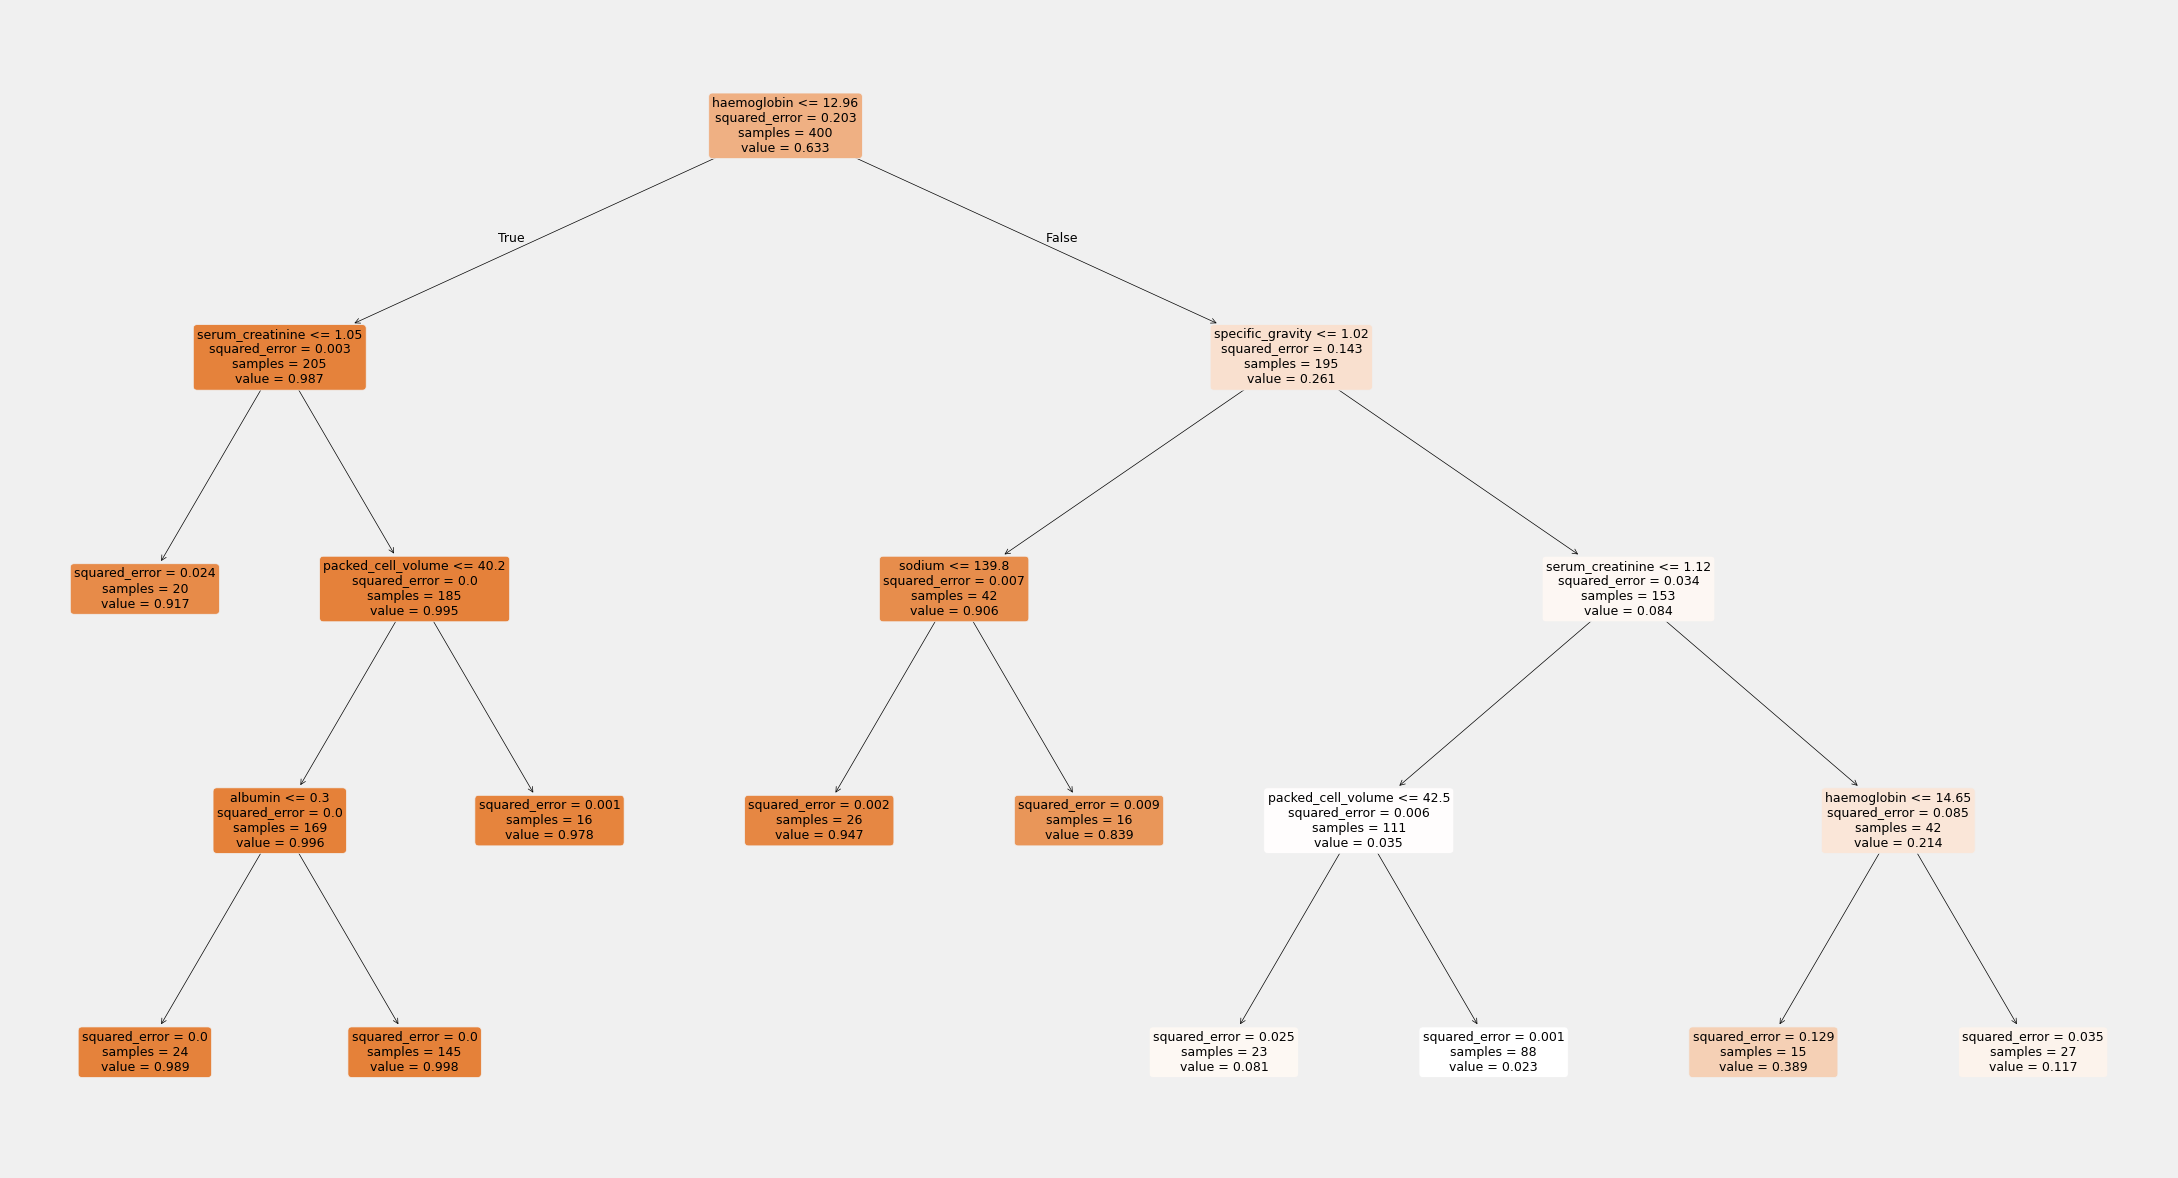

In [46]:
# --- ÉTAPE 4 : Visualisation de l'Arbre Distillé ---
print("🌳 STRUCTURE DE L'ARBRE ÉTUDIANT DISTILLÉ (Pseudo-code clinique) :")
print("=" * 70)
tree_rules_text = export_text(student_tree, feature_names=list(X_train.columns))
print(tree_rules_text)
print("=" * 70)
print("💡 Chaque feuille donne une probabilité CKD. Seuil de décision : 0.5")
print()

fig, ax = plt.subplots(figsize=(22, 12))
ax.set_title(
    "Arbre de Décision Distillé depuis la Forêt Aléatoire (130 arbres → 1 arbre)\n"
    "Diagnostic de la Maladie Rénale Chronique — Profondeur Maximale : 4",
    fontsize=14, fontweight='bold', pad=15
)
plot_tree(
    student_tree,
    feature_names=list(X_train.columns),
    filled=True,
    rounded=True,
    fontsize=9,
    precision=3,
    ax=ax
)
plt.tight_layout()
plt.show()

In [47]:
# --- Statistiques textuelles : arbre distillé ---
# Importance des variables dans l'arbre étudiant (impureté Gini)
imp_tree = pd.Series(
    student_tree.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print("📊 IMPORTANCE DES VARIABLES DANS L'ARBRE DISTILLÉ (Gini)")
print("=" * 65)
for feat, score in imp_tree.items():
    if score > 0:
        pct = 100 * score / imp_tree.sum()
        print(f"  {feat:32s}  {score:.4f}  ({pct:5.1f} %)")
print()
# Résumé des seuils principaux (racine et premiers nœuds)
print("💡 Les règles et seuils détaillés figurent dans l'arbre texte (export_text) ci-dessus.")
print("   Seuil de décision clinique : probabilité feuille ≥ 0.5 → prédiction CKD.")

📊 IMPORTANCE DES VARIABLES DANS L'ARBRE DISTILLÉ (Gini)
  haemoglobin                       0.6941  ( 69.4 %)
  specific_gravity                  0.2894  ( 28.9 %)
  serum_creatinine                  0.0142  (  1.4 %)
  sodium                            0.0015  (  0.2 %)
  packed_cell_volume                0.0009  (  0.1 %)
  albumin                           0.0000  (  0.0 %)

💡 Les règles et seuils détaillés figurent dans l'arbre texte (export_text) ci-dessus.
   Seuil de décision clinique : probabilité feuille ≥ 0.5 → prédiction CKD.


### Comment lire cet arbre

La **racine** contient la variable la plus discriminante. À chaque nœud : condition de split (ex. haemoglobin ≤ 10,8), effectif, probabilité CKD. Les **feuilles** donnent la probabilité CKD pour un sous-groupe. La **couleur** : orange foncé = forte proba CKD, bleu = faible. Cet arbre peut être imprimé et affiché en néphrologie sans accès informatique.

<a id='6.3'></a>
<p style = "font-size : 35px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>6.3 — Désopacification de XGBoost : Interactions de Second Ordre via TreeSHAP</strong></p>

XGBoost accumule séquentiellement des arbres qui corrigent les pseudo-résidus (gradient négatif de la loss) : F_T(x) = Σ η·h_t(x). La simple analyse des **effets marginaux** est insuffisante car le boosting crée des **interactions** de 2e et 3e ordre (ex. créatinine × hypertension). L'**indice d'interaction SHAP** (décomposition de Shapley-Taylor) quantifie l'effet **synergique pur** entre deux variables après soustraction de leurs effets univariés. Le résultat est un tenseur 3D (n_patients × n_features × n_features) : diagonale = effets principaux, hors-diagonale = interactions. Le **dependence plot** montre comment l'effet de haemoglobin sur le risque est modulé par diabetes_mellitus.

⏳ Calcul des valeurs SHAP pour XGBoost...
✅ Valeurs SHAP calculées. Forme : (120, 24)



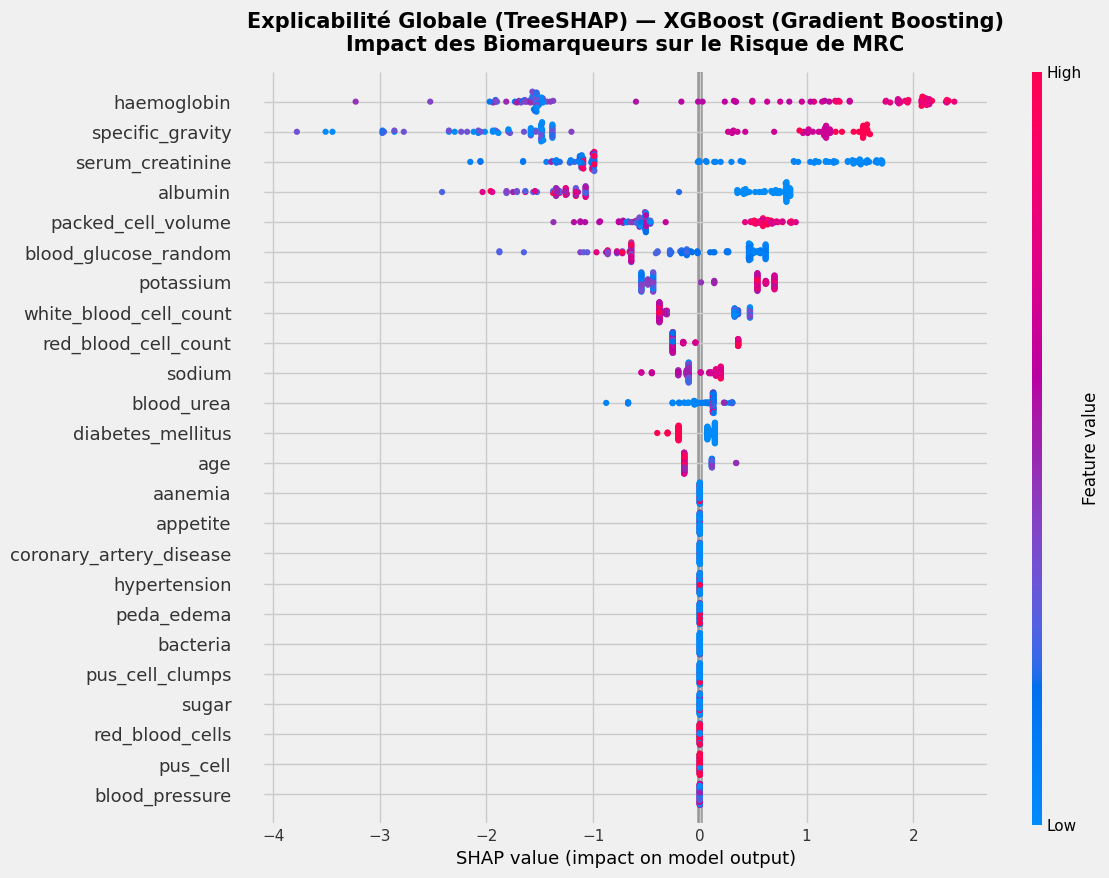

In [48]:
# --- Explicabilité du modèle XGBoost via TreeSHAP ---
import warnings
warnings.filterwarnings('ignore')

print("⏳ Calcul des valeurs SHAP pour XGBoost...")
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print(f"✅ Valeurs SHAP calculées. Forme : {shap_values_xgb.shape}")
print()

# Fixer la graine pour reproductibilité du beeswarm
np.random.seed(42)
# Utiliser l'objet Explanation (même correctif que pour la forêt) pour afficher les points
shap_vals_xgb = np.asarray(shap_values_xgb, dtype=np.float64)
X_test_vals = np.asarray(X_test, dtype=np.float64)
explanation_xgb = shap.Explanation(
    values=shap_vals_xgb,
    data=X_test_vals,
    feature_names=list(X_test.columns)
)
ax = shap.plots.beeswarm(
    explanation_xgb,
    max_display=24,
    show=False,
    plot_size=(12, 9),
    s=20
)
ax.set_title(
    "Explicabilité Globale (TreeSHAP) — XGBoost (Gradient Boosting)\n"
    "Impact des Biomarqueurs sur le Risque de MRC",
    fontsize=15, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

In [49]:
# --- Statistiques textuelles (équivalent Bar Plot + Beeswarm) — XGBoost ---
df_shap_xgb = pd.DataFrame(shap_values_xgb, columns=X_test.columns.tolist())

# 1) Importance globale : Mean |SHAP Value|
importance_xgb = df_shap_xgb.abs().mean().sort_values(ascending=False)
print("📊 CLASSEMENT D'IMPORTANCE GLOBALE (Mean |SHAP|) — XGBoost")
print("=" * 65)
for feat, score in importance_xgb.items():
    pct = 100 * score / importance_xgb.sum()
    print(f"  {feat:32s}  {score:.4f}  ({pct:5.1f} %)")
print()

# 2) Corrélation valeur réelle ↔ SHAP
print("📈 CORRÉLATION (Spearman) : Valeur de la variable ↔ SHAP Value")
print("-" * 65)
X_test_df_xgb = pd.DataFrame(X_test_vals, columns=X_test.columns.tolist())
for col in X_test.columns:
    s_shap = pd.Series(df_shap_xgb[col].values, index=X_test_df_xgb.index)
    r = X_test_df_xgb[col].corr(s_shap, method="spearman")
    if pd.notna(r):
        print(f"  {col:32s}  r = {r:+.3f}")
print()

# 3) Statistiques descriptives — Top 5 variables
top5_xgb = importance_xgb.head(5).index.tolist()
print("📉 STATISTIQUES DESCRIPTIVES (SHAP) — Top 5 variables (XGBoost)")
print(df_shap_xgb[top5_xgb].describe().round(4))

📊 CLASSEMENT D'IMPORTANCE GLOBALE (Mean |SHAP|) — XGBoost
  haemoglobin                       1.5904  ( 19.3 %)
  specific_gravity                  1.5571  ( 18.9 %)
  serum_creatinine                  1.1512  ( 14.0 %)
  albumin                           1.0273  ( 12.5 %)
  packed_cell_volume                0.6113  (  7.4 %)
  blood_glucose_random              0.5377  (  6.5 %)
  potassium                         0.5272  (  6.4 %)
  white_blood_cell_count            0.3756  (  4.6 %)
  red_blood_cell_count              0.2674  (  3.2 %)
  sodium                            0.1553  (  1.9 %)
  blood_urea                        0.1490  (  1.8 %)
  diabetes_mellitus                 0.1410  (  1.7 %)
  age                               0.1404  (  1.7 %)
  blood_pressure                    0.0000  (  0.0 %)
  red_blood_cells                   0.0000  (  0.0 %)
  sugar                             0.0000  (  0.0 %)
  pus_cell_clumps                   0.0000  (  0.0 %)
  pus_cell              

Le beeswarm ne capture que les **effets marginaux**. XGBoost modélise des **interactions non linéaires** : deux variables peuvent avoir un effet synergique. On calcule le **tenseur d'interaction SHAP** et on visualise un **dependence plot** : comment l'effet de haemoglobin est-il modulé par diabetes_mellitus ? (Calcul plus coûteux en mémoire.)

⏳ Calcul du tenseur d'interactions SHAP (Shapley-Taylor)...
✅ Tenseur d'interactions calculé. Forme : (120, 24, 24)



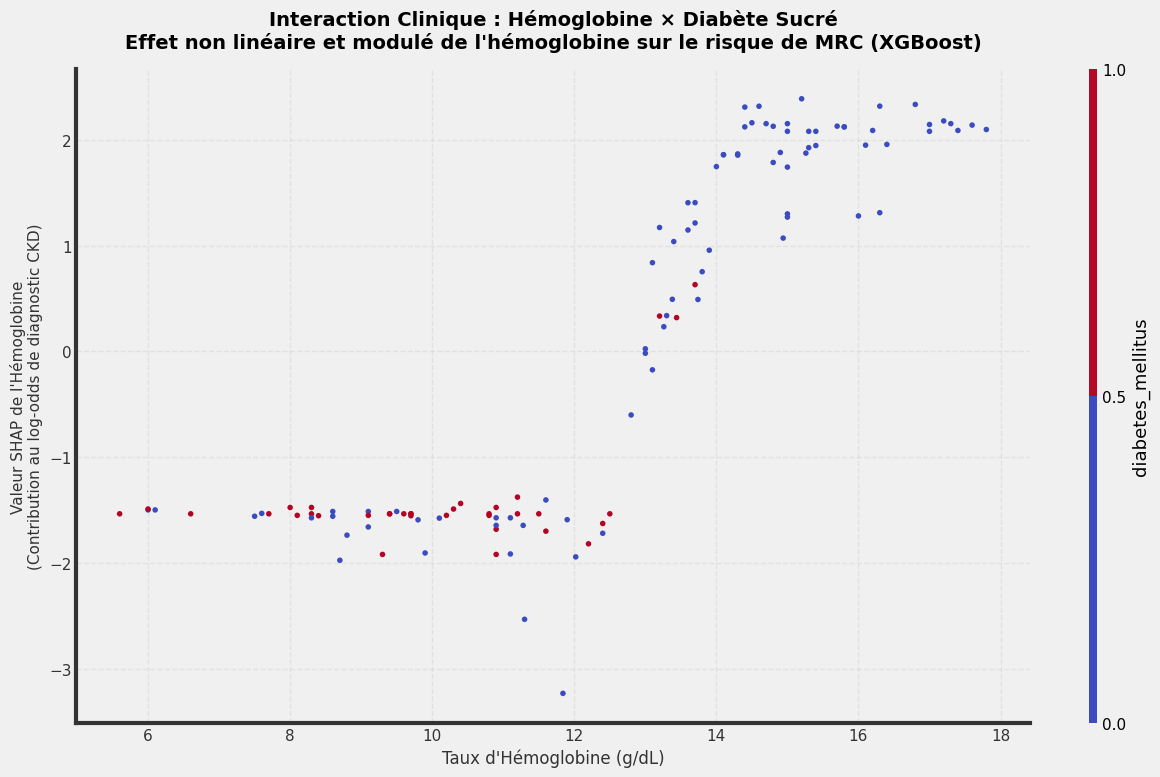

In [50]:
# --- Calcul du Tenseur d'Interactions SHAP (Shapley-Taylor) ---
np.random.seed(42)
print("⏳ Calcul du tenseur d'interactions SHAP (Shapley-Taylor)...")
shap_interaction_values = explainer_xgb.shap_interaction_values(X_test)

print(f"✅ Tenseur d'interactions calculé. Forme : {shap_interaction_values.shape}")
print()

# Passer des tableaux numpy et laisser SHAP créer la figure (évite un graphique vide)
shap_vals_xgb = np.asarray(shap_values_xgb, dtype=np.float64)
X_test_vals = np.asarray(X_test, dtype=np.float64)
shap.dependence_plot(
    "haemoglobin",
    shap_vals_xgb,
    X_test_vals,
    interaction_index="diabetes_mellitus",
    feature_names=list(X_test.columns),
    show=False,
    cmap=plt.get_cmap("coolwarm")
)
ax = plt.gca()
ax.figure.set_size_inches(13, 8)
ax.set_title(
    "Interaction Clinique : Hémoglobine × Diabète Sucré\n"
    "Effet non linéaire et modulé de l'hémoglobine sur le risque de MRC (XGBoost)",
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel("Taux d'Hémoglobine (g/dL)", fontsize=12)
ax.set_ylabel("Valeur SHAP de l'Hémoglobine\n(Contribution au log-odds de diagnostic CKD)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [51]:
# --- Statistiques textuelles : interaction Hémoglobine × Diabète ---
col_hemo, col_dm = "haemoglobin", "diabetes_mellitus"
cols = list(X_test.columns)
df_shap_xgb_local = pd.DataFrame(shap_values_xgb, columns=cols)
X_test_df_local = pd.DataFrame(X_test_vals, columns=cols)
df_hemo_dm = pd.DataFrame({
    "haemoglobin": X_test_df_local[col_hemo],
    "SHAP_haemoglobin": df_shap_xgb_local[col_hemo],
    "diabetes_mellitus": X_test_df_local[col_dm]
}).dropna(subset=["haemoglobin", "SHAP_haemoglobin"])

print("📊 MOYENNE SHAP (hémoglobine) PAR GROUPE DIABÈTE")
print("   (Contribution de l'hémoglobine au risque MRC selon diabète)")
print("-" * 65)
stats_by_dm = df_hemo_dm.groupby(col_dm)["SHAP_haemoglobin"].agg(["mean", "std", "count"])
print(stats_by_dm.round(4))
print()
print("📈 Corrélation Hémoglobine ↔ SHAP (hémoglobine) par groupe diabète :")
for dm_val in df_hemo_dm[col_dm].dropna().unique():
    sub = df_hemo_dm[df_hemo_dm[col_dm] == dm_val]
    r = sub["haemoglobin"].corr(sub["SHAP_haemoglobin"], method="spearman")
    print(f"   {col_dm} = {dm_val}: r = {r:+.3f}")
print()
print("💡 Une corrélation négative signifie : plus l'hémoglobine baisse, plus la contribution au risque CKD augmente.")

📊 MOYENNE SHAP (hémoglobine) PAR GROUPE DIABÈTE
   (Contribution de l'hémoglobine au risque MRC selon diabète)
-----------------------------------------------------------------
                     mean     std  count
diabetes_mellitus                       
0.0                0.5669  1.6606     85
1.0               -1.3931  0.5789     35

📈 Corrélation Hémoglobine ↔ SHAP (hémoglobine) par groupe diabète :
   diabetes_mellitus = 0.0: r = +0.860
   diabetes_mellitus = 1.0: r = +0.069

💡 Une corrélation négative signifie : plus l'hémoglobine baisse, plus la contribution au risque CKD augmente.


### Décryptage médical du graphique

Axe X = taux d'hémoglobine (g/dL). Axe Y = contribution SHAP (positif = hausse risque CKD). Couleur : rouge = diabétique (dm=1), bleu = non diabétique (dm=0). **Pattern 1** : la courbe descend globalement (hémoglobine haute = risque CKD diminué ; anémie = signe d'insuffisance rénale). **Pattern 2** : pour des valeurs intermédiaires (~10–12 g/dL), les points rouges sont au-dessus des bleus → patient anémique ET diabétique a un risque CKD supérieur. **Conclusion** : le diabète aggrave l'impact de l'anémie sur le risque rénal ; c'est la **néphropathie diabétique** que l'algorithme a appris implicitement.